In [53]:
!nvidia-smi

Thu Apr  9 17:48:09 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.54.03              Driver Version: 535.54.03    CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A30                     On  | 0000D850:00:00.0 Off |                    0 |
| N/A   25C    P0              32W / 165W |   4273MiB / 24576MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt

DATA_ROOT = 'data/test-task'
SAVE_DIR = 'runs/09_04_26'
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

writer = SummaryWriter(SAVE_DIR)

device: cuda


In [56]:
import json

with open(os.path.join(DATA_ROOT, 'split.json')) as f:
    split = json.load(f)

print('train sessions:', len(split['train']))
print('val sessions:', len(split['val']))

train sessions: 56
val sessions: 14


In [ ]:
SOURCE_ID = {'top': 0, 'bottom': 1}

def read_samples(sessions):
    samples = []
    for sess in sessions:
        for source in ['top', 'bottom']:
            coord_file = os.path.join(DATA_ROOT, sess, f'coords_{source}.json')
            
            if not os.path.exists(coord_file):
                continue

            with open(coord_file) as f:
                data = json.load(f)

            for item in data:
                file1_parts = item['file1_path'].split(os.sep)[-2:]
                file2_parts = item['file2_path'].split(os.sep)[-2:]

                door2_path = os.path.join(DATA_ROOT, sess, *file1_parts)
                src_path = os.path.join(DATA_ROOT, sess, *file2_parts)

                d2_dict = {p['number']: p for p in item['image1_coordinates']}
                src_dict = {p['number']: p for p in item['image2_coordinates']}
                
                common_numbers = sorted(set(d2_dict.keys()) & set(src_dict.keys()))

                if not common_numbers:
                    continue

                src_pts_list = []
                dst_pts_list = []
                
                for num in common_numbers:
                    ps = src_dict[num]
                    pd = d2_dict[num]
                    src_pts_list.append([ps['x'], ps['y']])
                    dst_pts_list.append([pd['x'], pd['y']])

                samples.append({
                    'source_id': SOURCE_ID[source],
                    'src_path': src_path,
                    'door2_path': door2_path,
                    'pts_src': src_pts_list,
                    'pts_dst': dst_pts_list,
                })
    return samples

train_samples = read_samples(split['train'])
val_samples = read_samples(split['val'])

for k, v in train_samples[0].items():
    print(f'{k}: {v}')

source_id: 0
src_path: data/test-task/train/camera_door2_2025-11-27_14-26-36/top/frame_000159.jpg
door2_path: data/test-task/train/camera_door2_2025-11-27_14-26-36/door2/frame_000146.jpg
pts_src: [[1954.1343221969469, 134.74178195277221], [1533.2763001507583, 125.78735595178948], [1134.8043431070264, 152.65063395473769], [2007.8608782028434, 242.19489396456507], [1040.7828700967077, 260.10374596653054], [946.7613970863889, 358.60243197734064], [476.65403203479514, 815.2781580274603], [1900.4077661910505, 192.94555095916002], [1775.0458021772922, 183.99112495817727], [1694.4559681684475, 183.99112495817727], [1582.5256431561634, 197.42276395965138], [1452.6864661419136, 188.46833795866866], [1354.1877801311034, 201.89997696014277], [1264.643520121276, 206.37718996063413], [1134.8043431070264, 219.80882896210824], [1980.997600199895, 286.96702396947876], [1864.5900621871194, 286.96702396947876], [1600.4344951581288, 376.51128397930614], [1421.345975138474, 389.9429229807802], [1224.34860

In [59]:
len(train_samples), len(val_samples)

(298, 80)

In [60]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

transform = transforms.Compose([
    transforms.Resize((360, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

ORIG_H, ORIG_W = 1800, 3200

class PointDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        src_img = transform(Image.open(s['src_path']).convert('RGB'))
        door2_img = transform(Image.open(s['door2_path']).convert('RGB'))

        source_id = torch.tensor(s['source_id'], dtype=torch.long)

        xy_src = torch.tensor(s['pts_src'], dtype=torch.float32)
        xy_dst = torch.tensor(s['pts_dst'], dtype=torch.float32)

        xy_src[:, 0] /= ORIG_W
        xy_src[:, 1] /= ORIG_H
        xy_dst[:, 0] /= ORIG_W
        xy_dst[:, 1] /= ORIG_H

        return src_img, door2_img, source_id, xy_src, xy_dst

In [61]:
train_dataset = PointDataset(train_samples)
val_dataset = PointDataset(val_samples)

def collate_fn(batch):
    src_imgs = []
    door2_imgs = []
    source_ids = []
    pts_src_flat = []
    pts_dst_flat = []
    batch_indices = []

    for i, (src_img, door2_img, source_id, xy_src, xy_dst) in enumerate(batch):
        src_imgs.append(src_img)
        door2_imgs.append(door2_img)
        source_ids.append(source_id)
        pts_src_flat.append(xy_src)
        pts_dst_flat.append(xy_dst)

        batch_indices.extend([i] * len(xy_src))

    src_imgs = torch.stack(src_imgs)
    door2_imgs = torch.stack(door2_imgs)
    source_ids = torch.stack(source_ids)
    pts_src_flat = torch.cat(pts_src_flat, dim=0)
    pts_dst_flat = torch.cat(pts_dst_flat, dim=0)
    batch_indices = torch.tensor(batch_indices, dtype=torch.long)

    return src_imgs, door2_imgs, source_ids, pts_src_flat, pts_dst_flat, batch_indices

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

len(train_loader), len(val_loader)

(38, 10)

In [ ]:
class CoordMapNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        self.encoder = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )
        self.source_emb = nn.Embedding(2, 16)
        self.coord_mlp = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Linear(512 + 512 + 16 + 64, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2),
        )

    def forward(self, src_img, door2_img, source_id, xy_src, batch_idx):

        src_fmap = self.encoder(src_img)
        dst_fmap = self.encoder(door2_img)

        f_dst = self.pool(dst_fmap).flatten(1)

        N = xy_src.shape[0]
        grid = xy_src * 2 - 1
        grid = grid.view(N, 1, 1, 2)

        src_fmap_per_pt = src_fmap[batch_idx]
        sampled = torch.nn.functional.grid_sample(src_fmap_per_pt, grid, mode='bilinear', align_corners=True)
        f_src_local = sampled.flatten(1)

        f_dst_per_pt = f_dst[batch_idx]

        s_emb = self.source_emb(source_id)[batch_idx]
        xy_feat = self.coord_mlp(xy_src)

        x = torch.cat([f_src_local, f_dst_per_pt, s_emb, xy_feat], dim=1)
        return self.head(x)

In [66]:
EPOCHS = 40
LR = 1e-4

model = CoordMapNet().to(DEVICE)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [67]:
orig = torch.tensor([ORIG_W, ORIG_H], dtype=torch.float32, device=DEVICE)
best_l2 = float('inf')
train_losses = []
val_l2_arr = []

for epoch in range(EPOCHS):

    model.train()
    epoch_loss = 0

    # train
    for src_img, door2_img, source_id, xy_src, xy_dst, batch_idx in tqdm(train_loader, desc=f'train {epoch+1}/{EPOCHS}', leave=False):
        src_img = src_img.to(DEVICE)
        door2_img = door2_img.to(DEVICE)
        source_id = source_id.to(DEVICE)
        xy_src = xy_src.to(DEVICE)
        xy_dst = xy_dst.to(DEVICE)
        batch_idx = batch_idx.to(DEVICE)

        pred = model(src_img, door2_img, source_id, xy_src, batch_idx)
        loss = criterion(pred, xy_dst)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # val
    model.eval()
    all_dists = []

    with torch.no_grad():
        for src_img, door2_img, source_id, xy_src, xy_dst, batch_idx in tqdm(val_loader, desc=f'val {epoch+1}/{EPOCHS}', leave=False):
            src_img = src_img.to(DEVICE)
            door2_img = door2_img.to(DEVICE)
            source_id = source_id.to(DEVICE)
            xy_src = xy_src.to(DEVICE)
            xy_dst = xy_dst.to(DEVICE)
            batch_idx = batch_idx.to(DEVICE)
        
            pred = model(src_img, door2_img, source_id, xy_src, batch_idx)

            pred_px = pred * orig
            gt_px = xy_dst * orig
            dist = torch.norm(pred_px - gt_px, dim=1)
            all_dists.append(dist.cpu())

    l2 = torch.cat(all_dists).mean().item()
    val_l2_arr.append(l2)

    print(f'epoch {epoch+1}: train_loss = {avg_loss:.6f}, val_l2 = {l2:.2f}px')

    if l2 < best_l2:
        best_l2 = l2
        torch.save(model.state_dict(), ARTIFACTS / 'best.pt')
        print(f"Saved new best model at epoch {epoch+1}")
    torch.save(model.state_dict(), ARTIFACTS / 'last.pt')


print(f'Best val l2: {best_l2:.2f}px')

epoch 1: train_loss = 0.008069, val_l2 = 210.93px
Saved new best model at epoch 1


epoch 2: train_loss = 0.001476, val_l2 = 202.81px
Saved new best model at epoch 2


epoch 3: train_loss = 0.000995, val_l2 = 152.75px
Saved new best model at epoch 3


epoch 4: train_loss = 0.001016, val_l2 = 135.70px
Saved new best model at epoch 4


epoch 5: train_loss = 0.000757, val_l2 = 123.11px
Saved new best model at epoch 5


...

epoch 36: train_loss = 0.000127, val_l2 = 105.67px


epoch 37: train_loss = 0.000119, val_l2 = 105.25px


epoch 38: train_loss = 0.000114, val_l2 = 108.20px


epoch 39: train_loss = 0.000111, val_l2 = 106.66px


epoch 40: train_loss = 0.000115, val_l2 = 103.23px
Best val l2: 103.22px


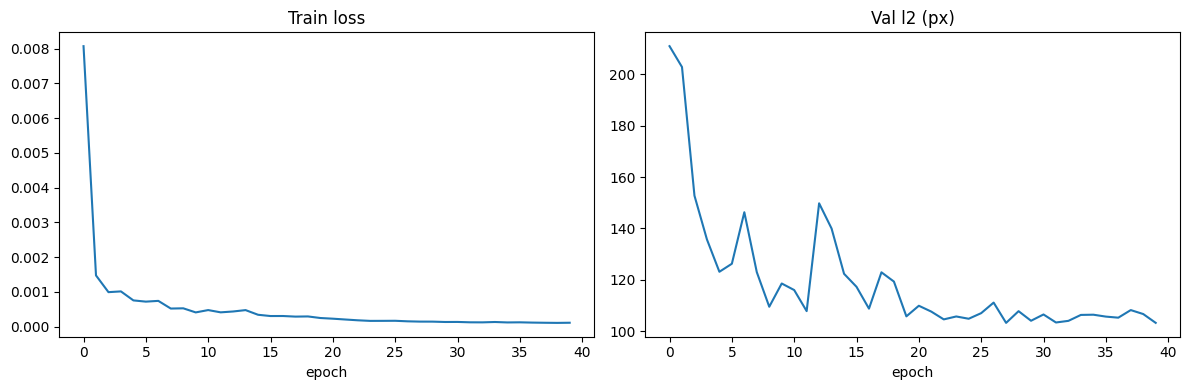

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Train loss')
ax1.set_xlabel('epoch')
ax2.plot(val_l2_arr)
ax2.set_title('Val l2 (px)')
ax2.set_xlabel('epoch')
plt.tight_layout()
plt.show()

In [70]:
model.eval()
orig = torch.tensor([ORIG_W, ORIG_H], dtype=torch.float32, device=DEVICE)

dists_top = []
dists_bottom = []

with torch.no_grad():
    for src_img, door2_img, source_id, xy_src, xy_dst, batch_idx in tqdm(val_loader, desc='eval'):
        src_img = src_img.to(DEVICE)
        door2_img = door2_img.to(DEVICE)
        source_id = source_id.to(DEVICE)
        xy_src = xy_src.to(DEVICE)
        xy_dst = xy_dst.to(DEVICE)
        batch_idx = batch_idx.to(DEVICE)

        pred = model(src_img, door2_img, source_id, xy_src, batch_idx)
        dist = torch.norm(pred * orig - xy_dst * orig, dim=1).cpu()

        source_id_cpu = source_id.cpu()
        source_per_pt = source_id_cpu[batch_idx.cpu()]

        dists_top.append(dist[source_per_pt == 0])
        dists_bottom.append(dist[source_per_pt == 1])

dists_top = torch.cat(dists_top)
dists_bottom = torch.cat(dists_bottom)
l2_top = dists_top.mean().item()
l2_bottom = dists_bottom.mean().item()

print(f'top -> door2 L2: {l2_top:.2f} px')
print(f'bottom -> door2 L2: {l2_bottom:.1f} px')

with open(os.path.join(SAVE_DIR, 'val_metrics.txt'), 'w') as f:
    f.write(f'top -> door2 L2: {l2_top} px\n')
    f.write(f'bottom -> door2 L2: {l2_bottom} px')


eval: 100%|██████████| 10/10 [00:10<00:00,  1.01s/it]

top -> door2 L2: 93.89 px
bottom -> door2 L2: 113.2 px


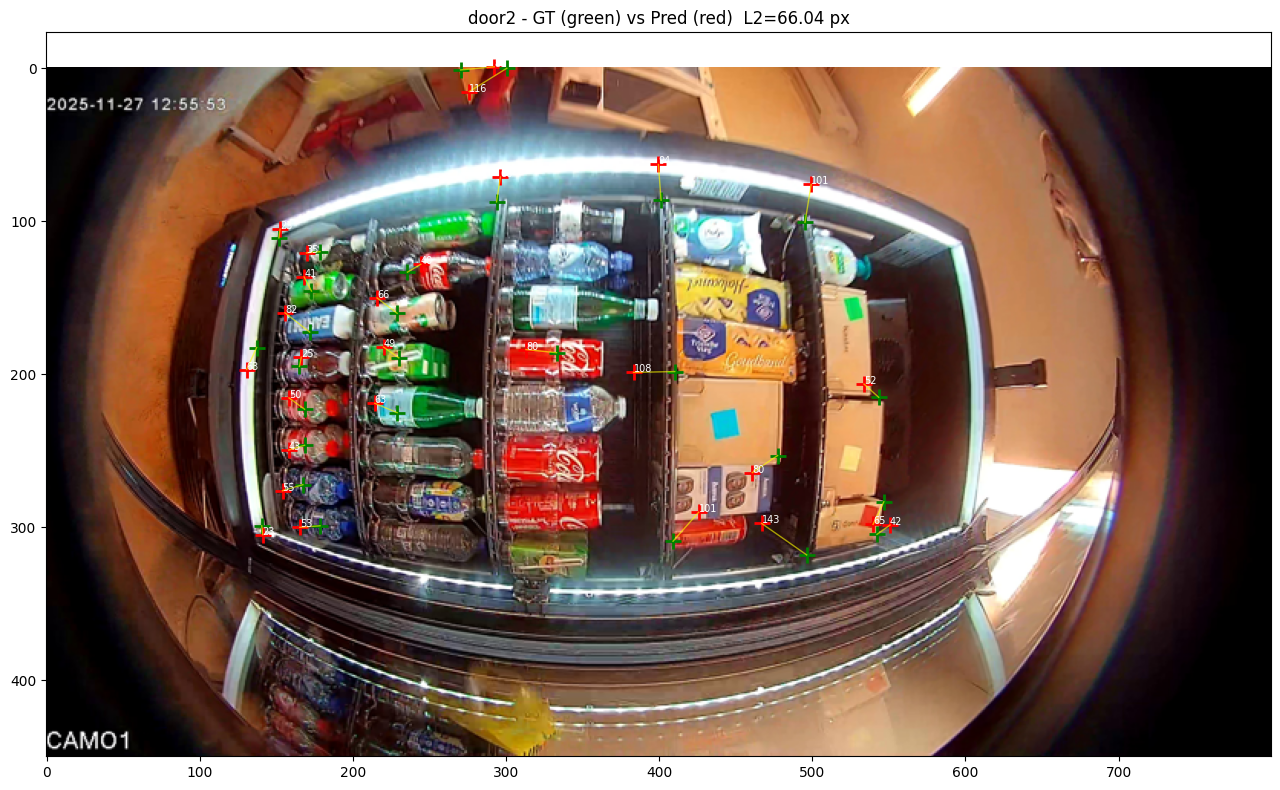

In [ ]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best.pt'), map_location=DEVICE))
model.eval()

s = val_samples[0]

src_t = transform(Image.open(s['src_path']).convert('RGB')).unsqueeze(0).to(DEVICE)
door2_t = transform(Image.open(s['door2_path']).convert('RGB')).unsqueeze(0).to(DEVICE)

pair_samples = [x for x in val_samples if x['src_path'] == s['src_path']]

pts_src = torch.tensor([[p['pts_src'][i] for i in range(len(p['pts_src']))] 
                         for p in [s]], dtype=torch.float32)

xy_src_all = torch.tensor(s['pts_src'], dtype=torch.float32)
xy_dst_all = torch.tensor(s['pts_dst'], dtype=torch.float32)
xy_src_norm = xy_src_all.clone()
xy_src_norm[:, 0] /= ORIG_W
xy_src_norm[:, 1] /= ORIG_H

N = len(xy_src_all)
src_imgs_rep = src_t.expand(1, -1, -1, -1)
door2_imgs_rep = door2_t.expand(1, -1, -1, -1)
source_id = torch.tensor([s['source_id']], device=DEVICE)
batch_idx = torch.zeros(N, dtype=torch.long, device=DEVICE)

with torch.no_grad():
    pred_norm = model(
        src_imgs_rep.to(DEVICE),
        door2_imgs_rep.to(DEVICE),
        source_id,
        xy_src_norm.to(DEVICE),
        batch_idx
    )

pred_px = pred_norm.cpu() * torch.tensor([ORIG_W, ORIG_H])
gt_px = xy_dst_all

errors = torch.norm(pred_px - gt_px, dim=1)

img_door2 = np.array(Image.open(s['door2_path']).convert('RGB').resize((800, 450)))
scale_x = 800 / ORIG_W
scale_y = 450 / ORIG_H

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.imshow(img_door2)
ax.set_title(f'door2 - GT (green) vs Pred (red)  L2={errors.mean():.2f} px')

for i in range(N):
    gx, gy = gt_px[i]
    px_, py_ = pred_px[i]

    ax.plot(gx * scale_x, gy * scale_y, 'g+', ms=12, mew=2)
    ax.plot(px_ * scale_x, py_ * scale_y, 'r+', ms=12, mew=2)
    ax.plot([gx * scale_x, px_ * scale_x], [gy * scale_y, py_ * scale_y],
            'yellow', lw=1, alpha=0.6)
    ax.annotate(f'{errors[i]:.0f}', (px_ * scale_x, py_ * scale_y),
                color='white', fontsize=7, ha='left')

plt.tight_layout()
plt.show()